In [90]:
import sys
from pathlib import Path
sys.path[:0] = [str(Path.cwd().parent)]

import numpy as np
import matplotlib.pyplot as plt

from scripts.Hamiltonian import Hamiltonian
from scripts.Lattice import Lattice
from scripts.self_consistency import bdg_sc

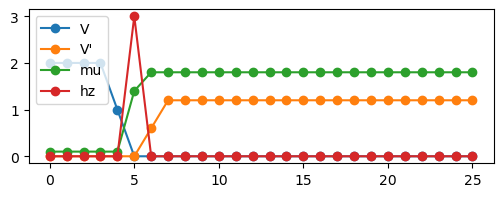

In [ ]:
widthD = 5
widthF = 1
widthP = 30

X, Y = widthD+widthF+widthP, 100
lattice = Lattice(X, Y)

t = 1
T = 0.001

muD = 0.1 * t
muP = 1.8 * t
muF = 1.4 * t
mu = np.zeros(lattice.X)
mu[:widthD] = muD
mu[widthD:widthF + widthD] = muF
mu[widthF + widthD:] = muP

h0 = 3 * t
h = np.zeros_like(mu)
h[widthD:widthF + widthD] = h0

U = None

V0 = 2 * t
V = np.zeros(lattice.X)
V[:widthD] = V0
V[widthD-1] = V0/2

V_prime0 = 1.2 * t
V_prime = V_prime0 * np.ones(lattice.X)
V_prime[:widthF+widthD] = 0 
V_prime[widthF+widthD] = V_prime0/2


plt.figure(figsize=(6,2))
if U is not None:
    plt.plot(U, '-o', label="U")
if V is not None:
    plt.plot(V, '-o', label="V")
if V_prime is not None:
    plt.plot(V_prime, '-o', label="V'",)
plt.plot(mu, '-o', label='mu')
plt.plot(h, '-o', label='hz')

plt.legend()

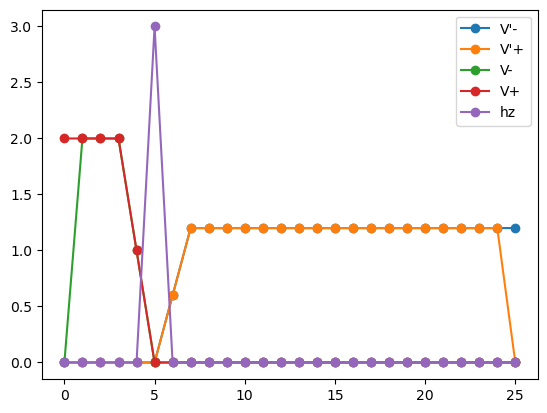

In [92]:
V_plus = np.r_[V[:-1], [0]]
V_minus = np.r_[[0], V[1:]]
Vprime_plus = np.r_[V_prime[:-1], [0]]
Vprime_minus = np.r_[[0], V_prime[1:]]

plt.plot(Vprime_minus, "-o", label="V'-")
plt.plot(Vprime_plus, "-o", label="V'+")
plt.plot(V_minus, "-o", label="V-")
plt.plot(V_plus, "-o", label="V+")
plt.plot(h, '-o', label='hz')
plt.legend()

In [93]:
H = Hamiltonian(t, mu, lattice, U=U, V_prime=V_prime, V=V,
                F_init=[0.5, 0.5, -0.5, -0.5],
                Fuu_init=[0.1, -0.1, 0.1j, -0.1j],
                Fdd_init=[0.1, -0.1, 0.1j, -0.1j],
                hx=h)

In [94]:
bdg_sc(H, atol=1e-3, rtol=0.1, maxiter=500, temperature=T,verbose=True)
F, Fuu, Fdd = H.get_correlations()

F0:
Absolute error: 0.03562842634958634
Relative error: 35628426349.586334
Average old: 0j
Average: (0.001701679557935754+0j)
F_xplus:
Absolute error: 0.25319750697786664
Relative error: 11906809404.809338
Average old: (0.08+0j)
Average: (0.06016949615269851+0j)
F_xmin:
Absolute error: 0.6368868212130819
Relative error: 2810943699.130618
Average old: (0.1+0j)
Average: (0.05098823458945339+0j)
F_yplus:
Absolute error: 0.3832482620944848
Relative error: 23090362606.716415
Average old: (-0.09615384615384616+0j)
Average: (-0.06354819296393628-0.0005458447546096871j)
F_ymin:
Absolute error: 0.3832482620944848
Relative error: 23090362606.716415
Average old: (-0.09615384615384616+0j)
Average: (-0.06354819296393628+0.0005458447546096871j)
Fuu_xplus:
Absolute error: 0.06183704209032442
Relative error: 19946226866.36518
Average old: (0.07600000000000001+0j)
Average: (0.0734475637163883+0j)
Fuu_xmin:
Absolute error: 0.1021418926042454
Relative error: 10745452744.839237
Average old: (-0.08+0j)
Ave

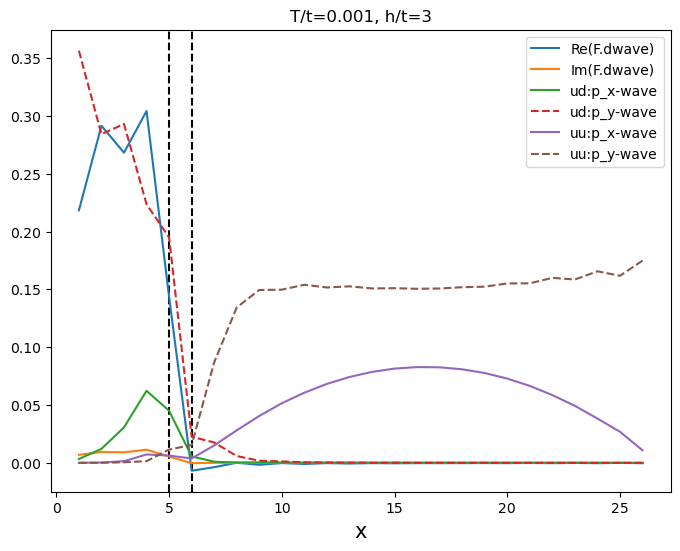

In [95]:
x = np.arange(1, widthD + widthF + widthP + 1)

fig, axs = plt.subplots(1, 1, figsize=(8, 6))
axs.set_title(f"T/t={T}, h/t={h0}")
axs.axvline(widthD, color='black', linestyle='--')
axs.axvline(widthD+widthF, color='black', linestyle='--')
axs.plot(x, np.real(F.dwave), label="Re(F.dwave)")
axs.plot(x, np.imag(F.dwave), label="Im(F.dwave)")
axs.plot(x, np.abs(F.px), label="ud:p_x-wave")
axs.plot(x, np.abs(F.py), "--", label="ud:p_y-wave")
axs.plot(x, np.abs(Fuu.px), label="uu:p_x-wave")
axs.plot(x, np.abs(Fuu.py), "--", label="uu:p_y-wave")
axs.set_xlabel("x", fontsize=15)
axs.legend()
plt.show()

In [96]:
temps = np.concatenate([
    np.arange(0.001, 0.009 + 1e-12, 0.001),
    np.arange(0.01, 1.00 + 1e-12, 0.01)
])  # 109 temps total
print(len(temps))

109
